In [5]:
import numpy as np
import csv
from sklearn.decomposition import PCA

In [11]:
filename = 'compTempR.csv'
dense_coding_table = []
for line in open(filename):
    dense_coding_table.append(line.strip('\n').split(',')[:-1])
for x in dense_coding_table[:10]:
    print(x)

['verse', 'eng', 'cym', 'deu', 'pol']
['40001011', 'at', 'yn', 'zu', '--']
['40005021', 'in', 'wrth', 'zu', '--']
['40009022', 'at', 'o', '--', 'od']
['40010019', 'at', 'yn', 'in', '--']
['40012005', 'on', 'ar', 'an', 'w']
['40012010', 'on', 'ar', 'an', 'w']
['40012011', 'on', 'ar', 'an', 'w']
['40012012', 'on', 'ar', 'an', 'w']
['40013040', 'at', 'yn', 'an', 'przy']


In [15]:
def get_dense_coding(filename = 'compTempR.csv'):
    dense_coding_table = []
    for line in open(filename):
        dense_coding_table.append(line.strip('\n').split(','))
    return dense_coding_table


def get_sparse_coding(dense_coding_table, no_response = '--'):
    languages = dense_coding_table[0][1:]
    sparse_dict = { language : {} for language in languages }
    sparse_coding_table = []
    for i,language in enumerate(languages, start=1):
 #       if language == 'eng': continue
        for row in dense_coding_table[1:]:
            for morpheme in row[i].split(' '):
                if morpheme == no_response: continue
                elif morpheme not in sparse_dict[language]: 
                    sparse_dict[language][morpheme] = len(sparse_dict[language])
    header = [language + '_' + morpheme for language in languages 
              for morpheme in sorted(sparse_dict[language], key = lambda k : sparse_dict[language][k])]
    for row in dense_coding_table[1:]:
        sparse_row = []
        for i,language in enumerate(languages, start=1):
#            if language == 'eng': continue
            sparse_row_i = [0 for j in range(len(sparse_dict[language]))]
            for morpheme in row[i].split(' '):
                if morpheme == no_response: continue
                else:
                    index = sparse_dict[language][morpheme]
                    sparse_row_i[index] = 1
            sparse_row.extend(sparse_row_i)
        sparse_coding_table.append(sparse_row)
    return header, sparse_coding_table, sparse_dict

header, sparse_coding_table, sparse_dict = get_sparse_coding(dense_coding_table, no_response = '--')
print('>>> sparse dict', sparse_dict)
print('>>> header', header)
for i in sparse_coding_table[:10]:
    print(i)

>>> sparse dict {'eng': {'at': 0, 'in': 1, 'on': 2}, 'cym': {'yn': 0, 'wrth': 1, 'o': 2, 'ar': 3, 'zero': 4, 'pryd': 5, 'ymhen': 6, 'mewn': 7, 'tridiau': 8, 'am': 9, 'tua': 10}, 'deu': {'zu': 0, 'in': 1, 'an': 2, 'zero': 3, 'nach': 4, 'um': 5, '_an': 6, 'bei': 7, 'von': 8, '_nach': 9}, 'pol': {'od': 0, 'w': 1, 'przy': 2, 'zero': 3, 'z': 4, 'o': 5, 'podczas': 6, 'po': 7, 'zaś': 8, 'na': 9}}
>>> header ['eng_at', 'eng_in', 'eng_on', 'cym_yn', 'cym_wrth', 'cym_o', 'cym_ar', 'cym_zero', 'cym_pryd', 'cym_ymhen', 'cym_mewn', 'cym_tridiau', 'cym_am', 'cym_tua', 'deu_zu', 'deu_in', 'deu_an', 'deu_zero', 'deu_nach', 'deu_um', 'deu__an', 'deu_bei', 'deu_von', 'deu__nach', 'pol_od', 'pol_w', 'pol_przy', 'pol_zero', 'pol_z', 'pol_o', 'pol_podczas', 'pol_po', 'pol_zaś', 'pol_na']
[1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[1, 0, 0, 0, 0, 

In [16]:
P = PCA()
coordinates = P.fit_transform(sparse_coding_table)
print(P.explained_variance_ratio_)

[2.15416394e-01 1.89227380e-01 1.14060814e-01 7.24429078e-02
 6.23271574e-02 4.36589859e-02 3.90269158e-02 3.67264631e-02
 3.39250391e-02 2.62009445e-02 2.18417009e-02 1.86266530e-02
 1.55982662e-02 1.34161571e-02 1.27556230e-02 1.13139791e-02
 1.11403209e-02 8.71246288e-03 7.79513951e-03 7.17896117e-03
 6.15895405e-03 5.24907154e-03 4.24587725e-03 4.03187753e-03
 3.32512022e-03 3.08569300e-03 2.36963685e-03 2.14737007e-03
 2.05766346e-03 1.92516443e-03 1.83068351e-03 1.57249874e-03
 6.08123383e-04 3.54554331e-33]


-0.22765607909677169 0.3855363206251169 40001011
0.3620095150058711 -0.5704274763287863 40005021
-0.5776097479145714 -0.043125170820210335 40009022
0.2587041808707211 0.5826945602403207 40010019
-0.7404389482156749 0.31845005714343094 40012005
-0.7404389482156752 0.31845005714343155 40012010
-0.7404389482156749 0.31845005714343205 40012011
-0.7404389482156755 0.31845005714343083 40012012
-0.3929347910694588 0.06577473623097381 40013040
-0.39293479106945794 0.06577473623097449 40013049
-0.6251146780399064 0.6150473489523185 40014001
0.5527597383053282 -0.7802089336475538 40016003
0.09909652803785586 -0.9308037198006169 40020001
-0.5837774498677122 -0.016912714780845536 40020009
0.552759738305329 -0.780208933647553 40021018
-0.5613834993140685 -0.02325397017405424 40023036
1.312557003067756 0.6002903094546974 40024019
1.266763883673823 -0.07834504700489126 40024020
-0.5613834993140688 -0.02325397017405538 40024034
-0.6441069848931494 0.11829206211546553 40024044
-0.1424756203900161 1.040

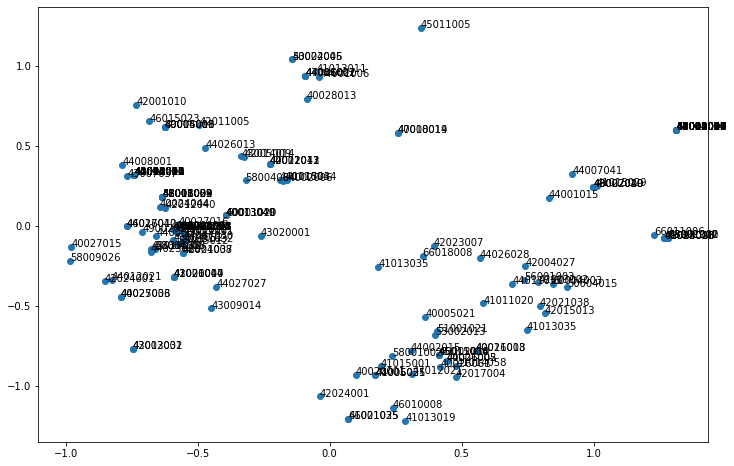

0 eng_at


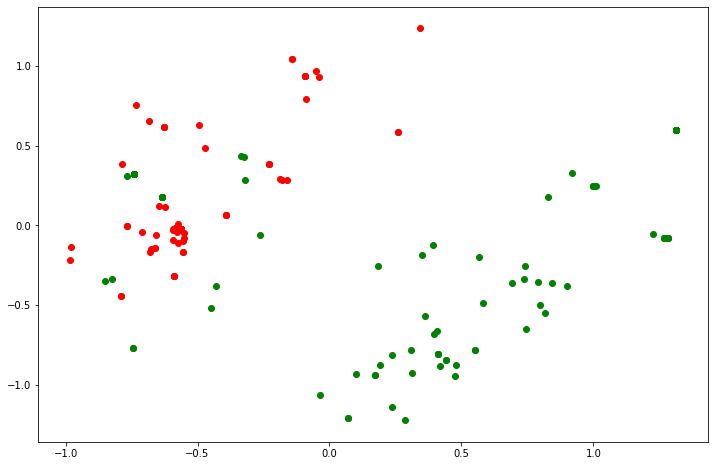

1 eng_in


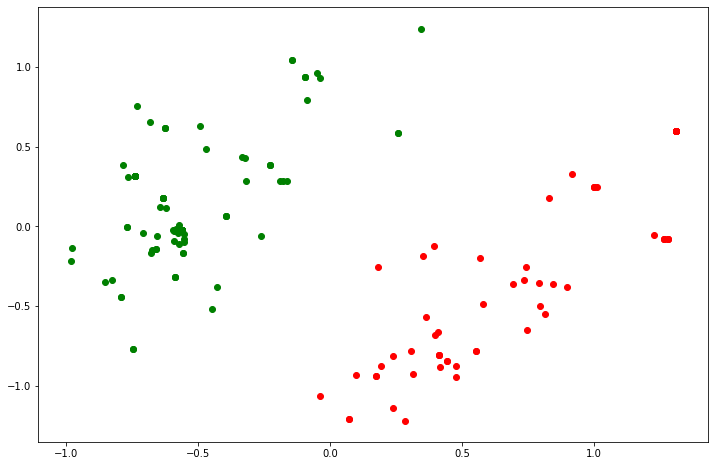

2 eng_on


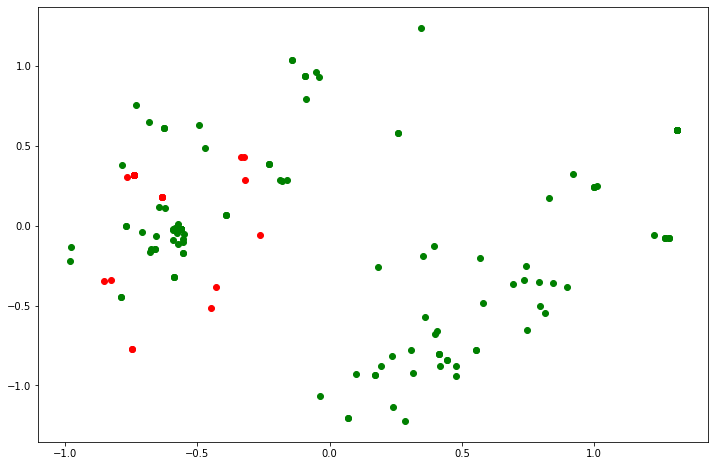

3 cym_yn


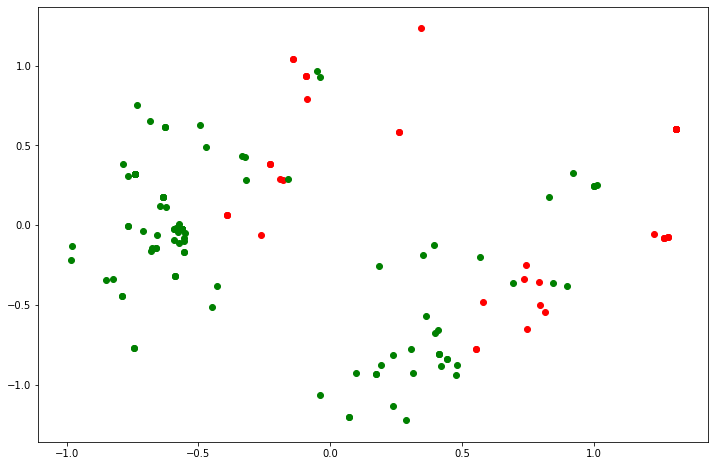

4 cym_wrth


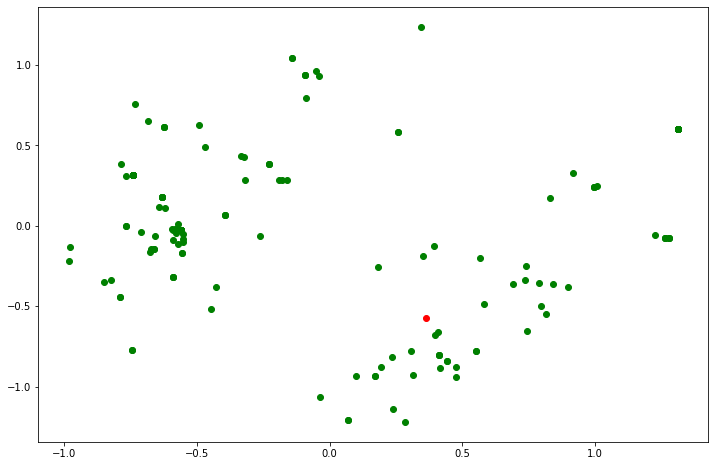

5 cym_o


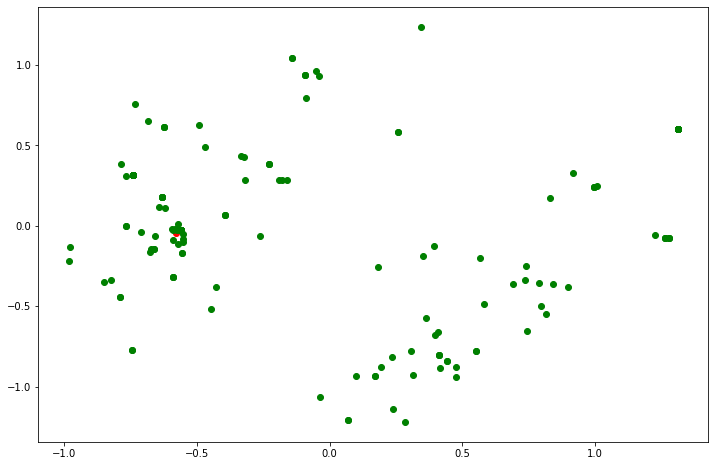

6 cym_ar


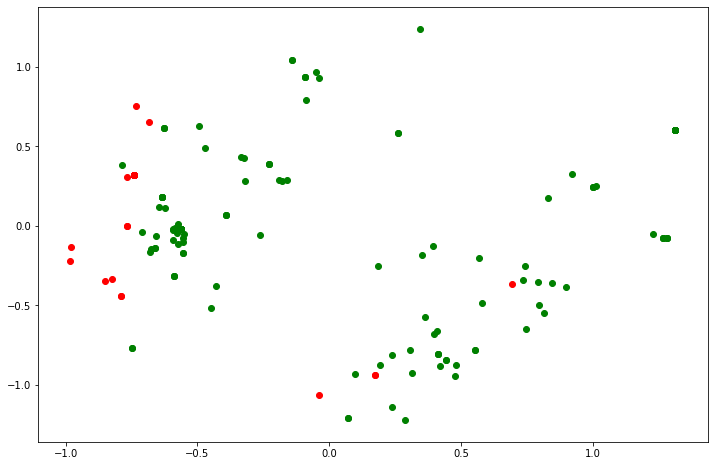

7 cym_zero


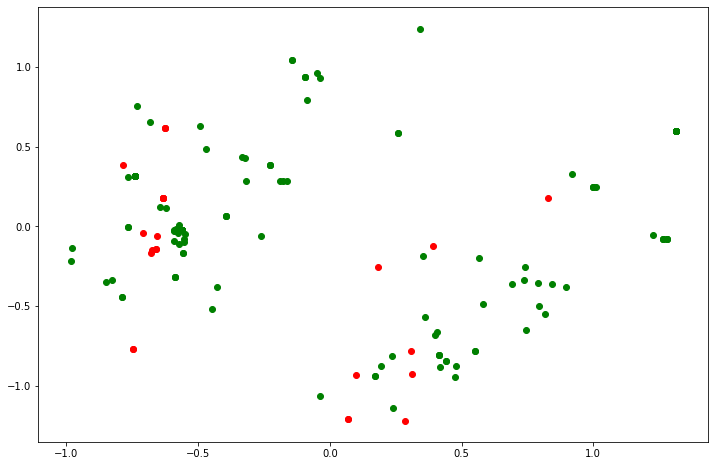

8 cym_pryd


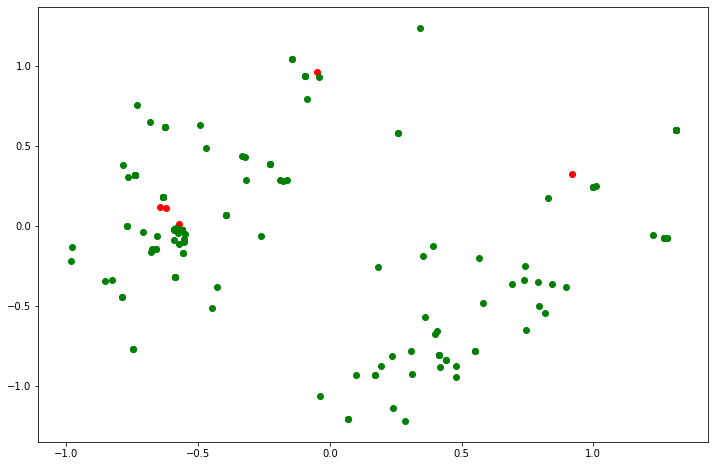

9 cym_ymhen


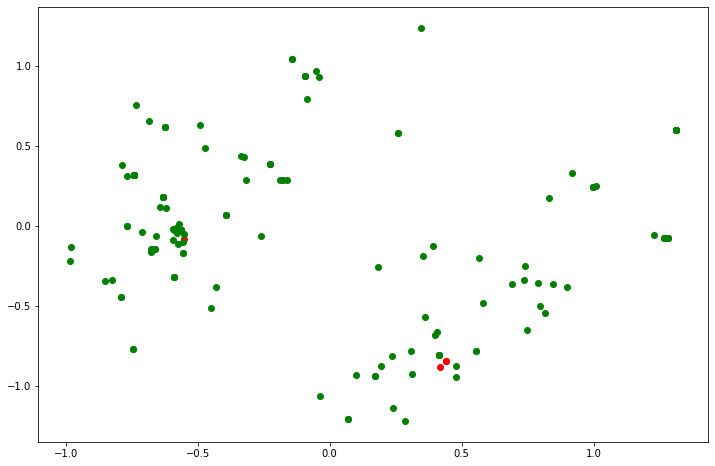

10 cym_mewn


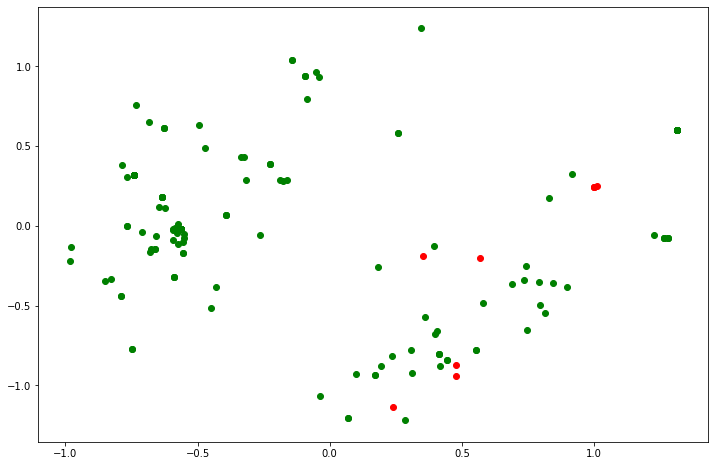

11 cym_tridiau


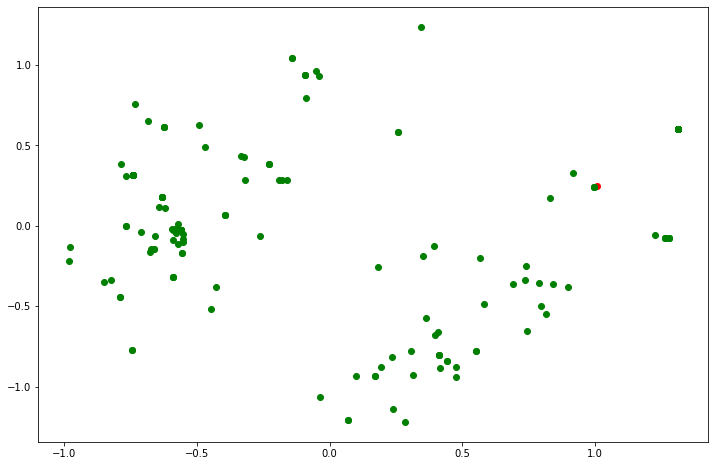

12 cym_am


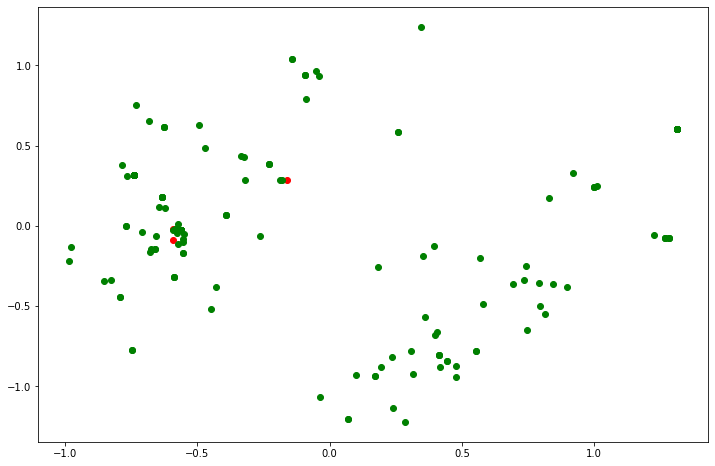

13 cym_tua


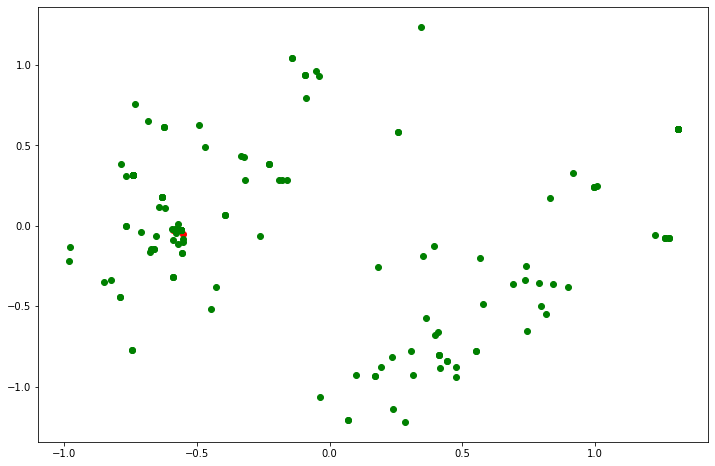

14 deu_zu


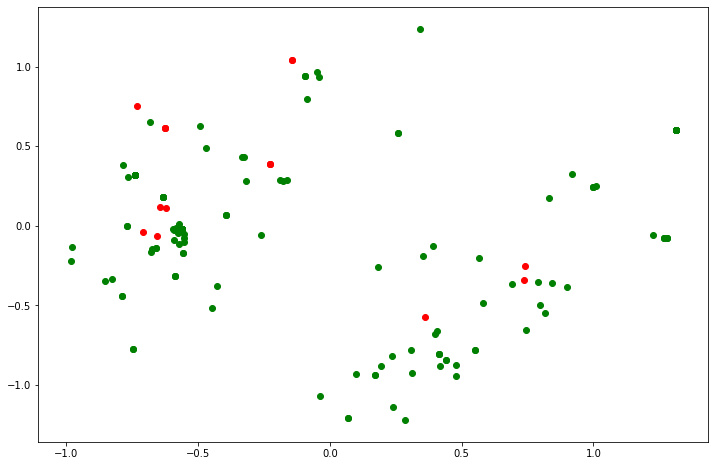

15 deu_in


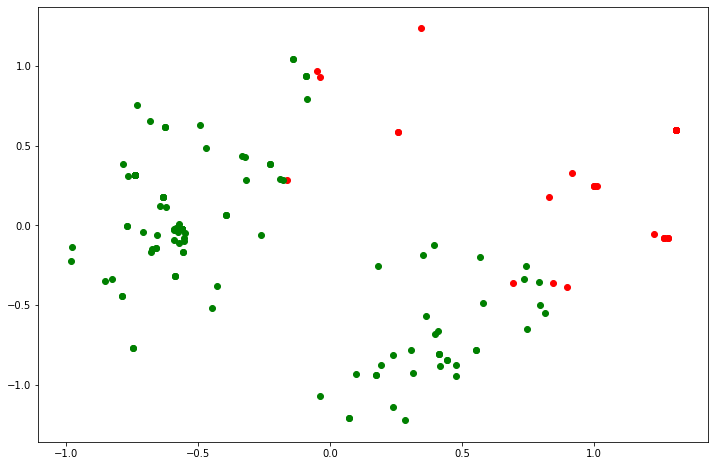

16 deu_an


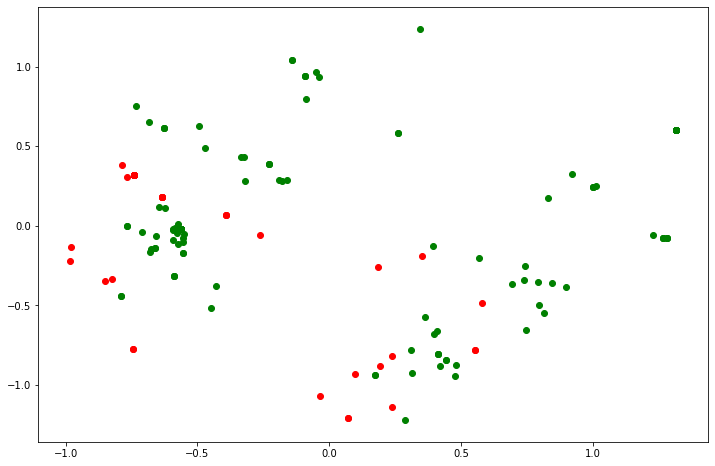

17 deu_zero


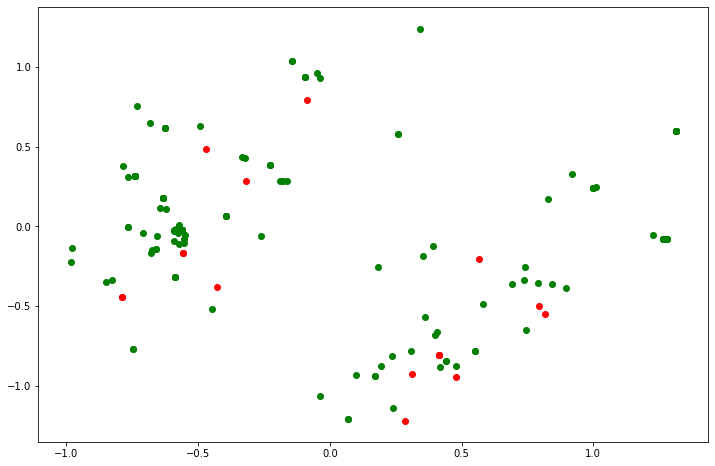

18 deu_nach


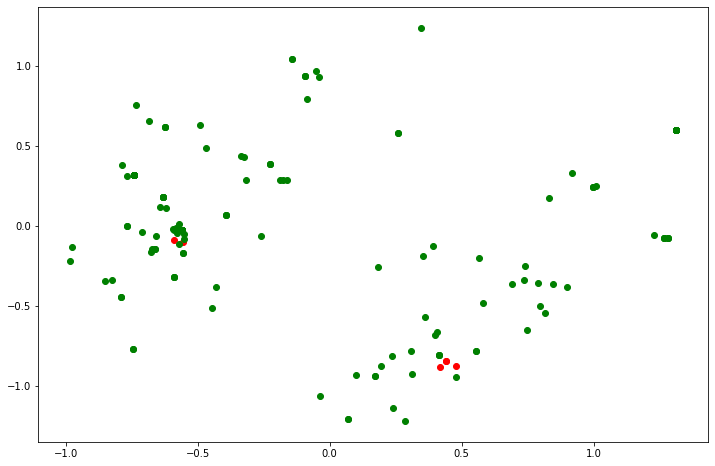

19 deu_um


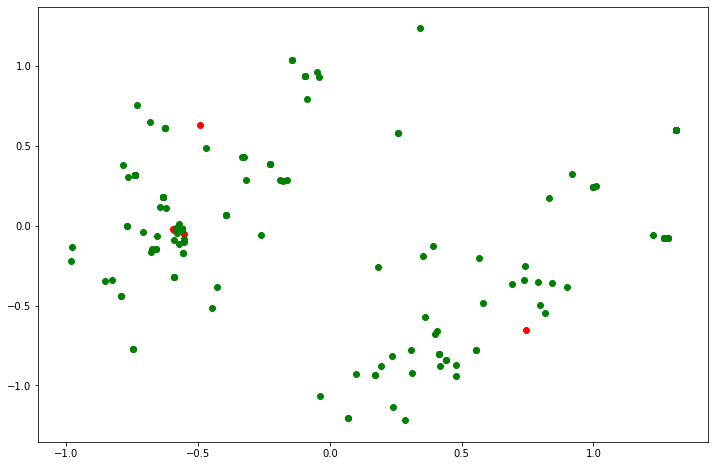

20 deu__an


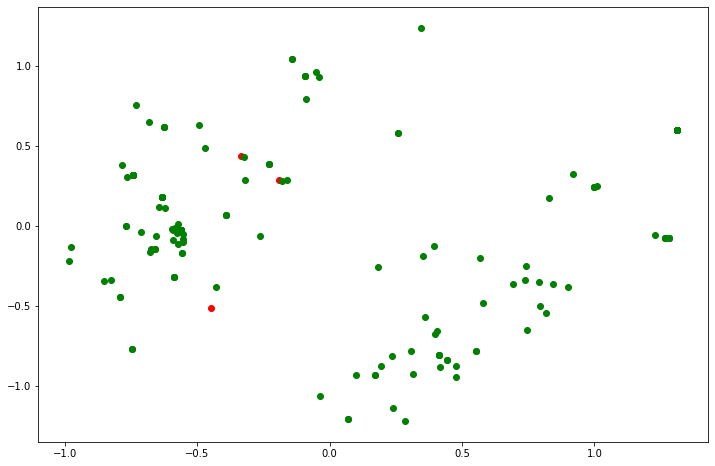

21 deu_bei


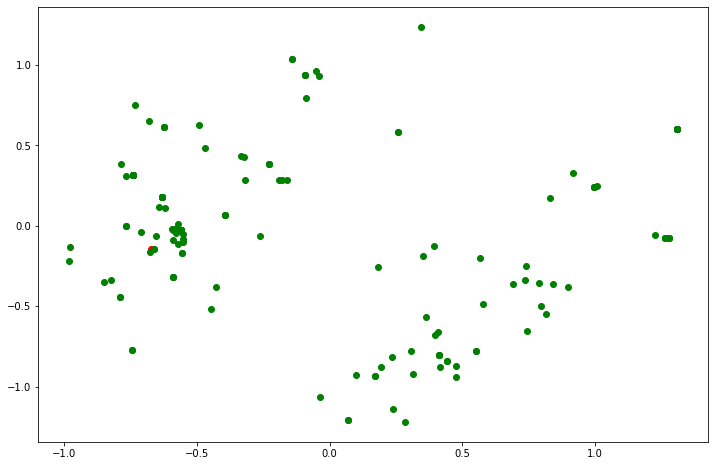

22 deu_von


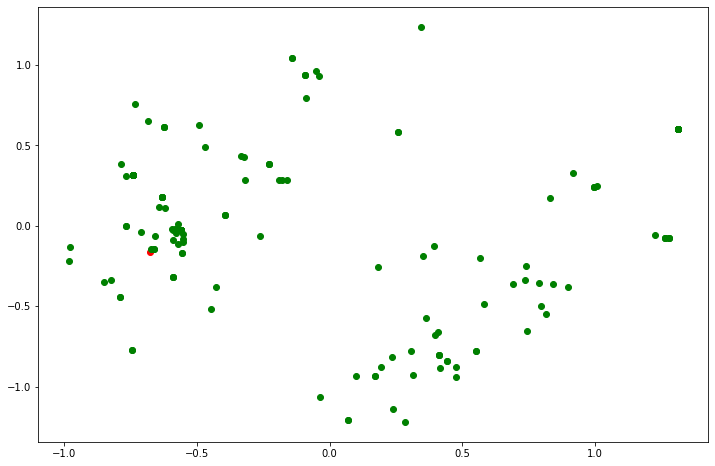

23 deu__nach


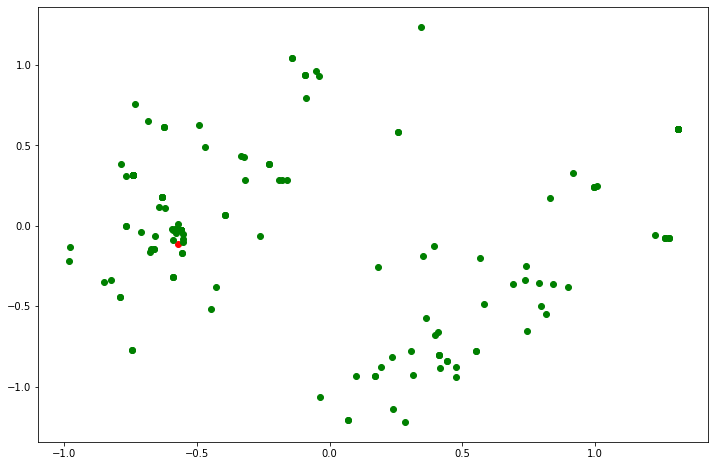

24 pol_od


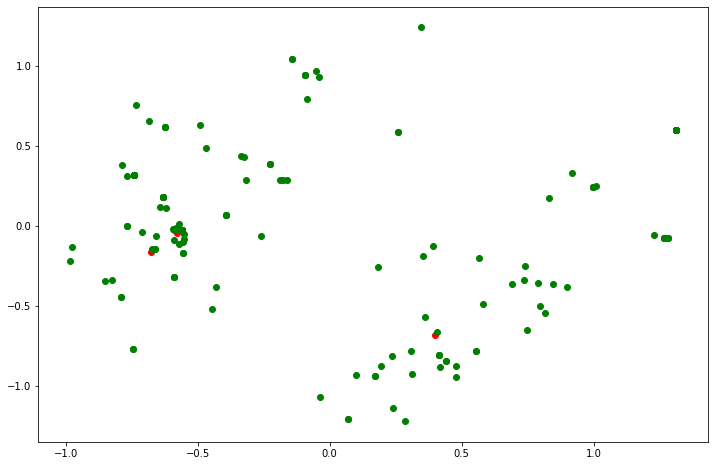

25 pol_w


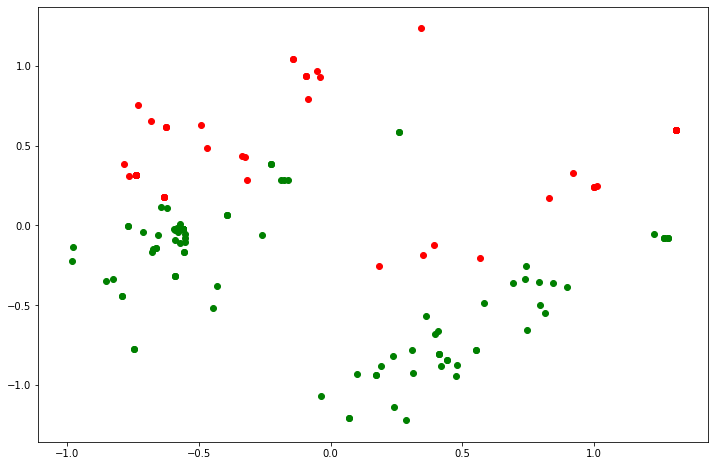

26 pol_przy


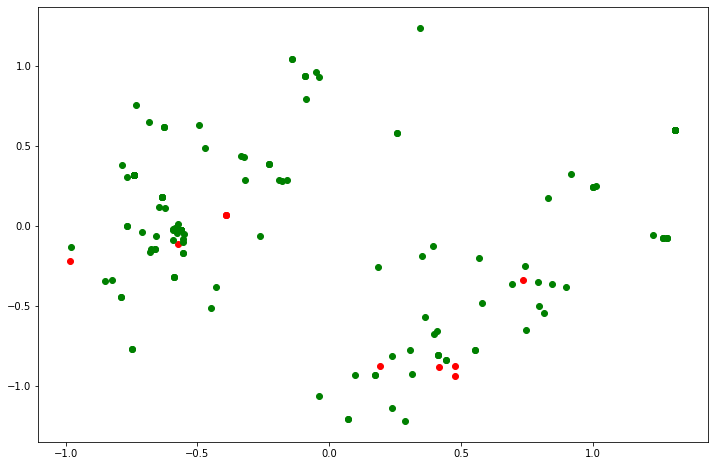

27 pol_zero


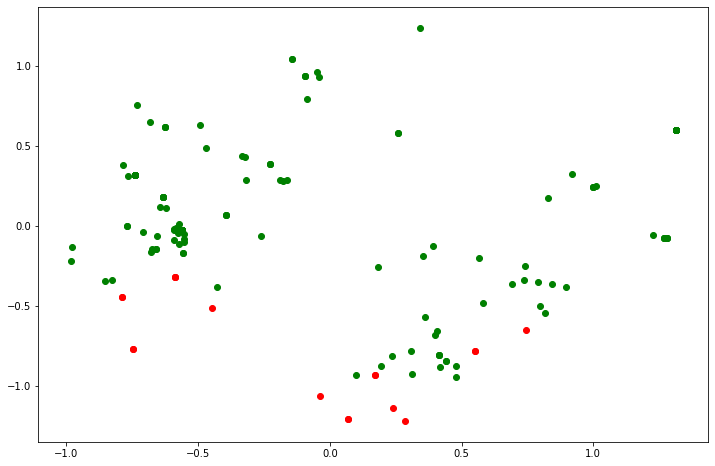

28 pol_z


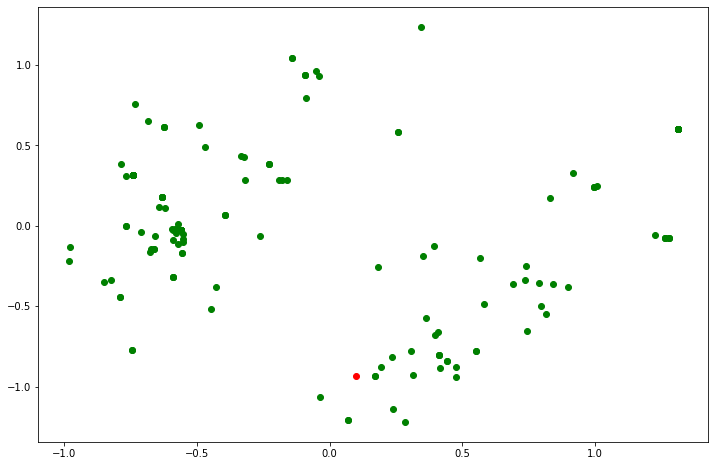

29 pol_o


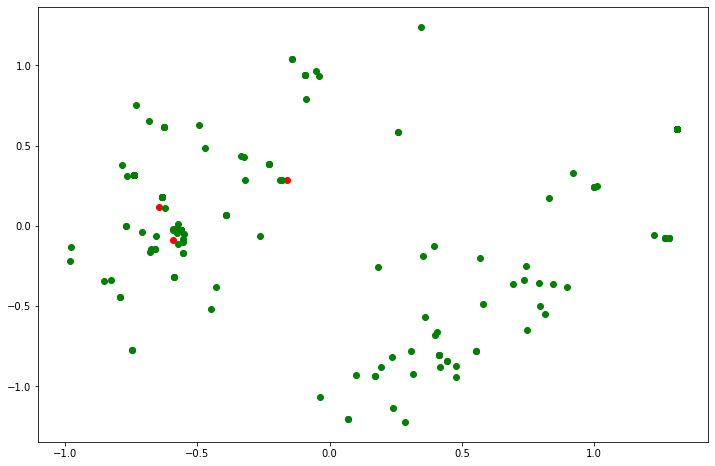

30 pol_podczas


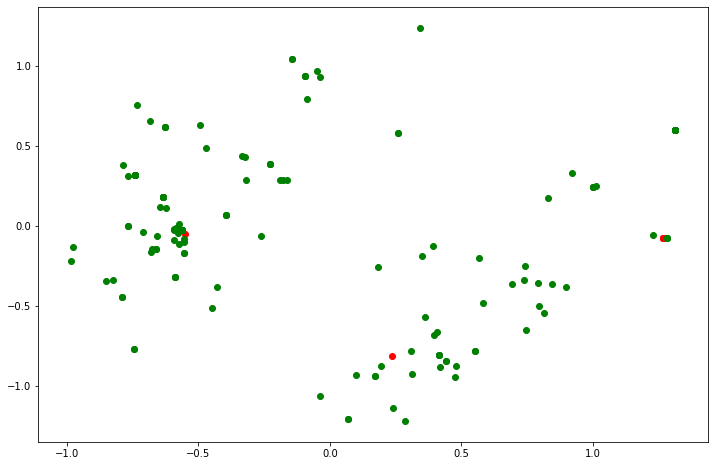

31 pol_po


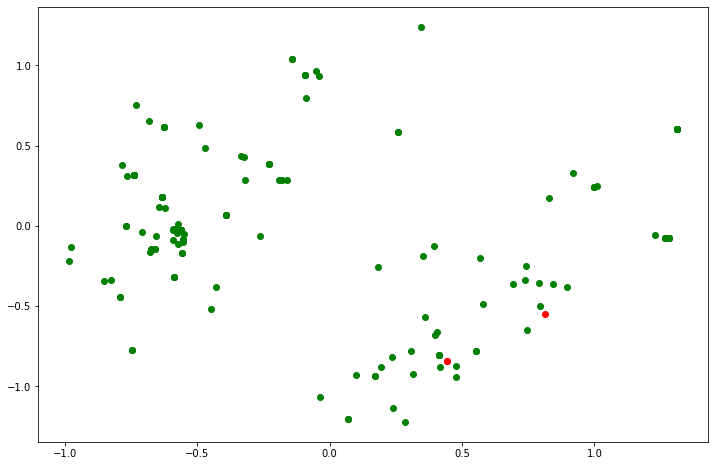

32 pol_zaś


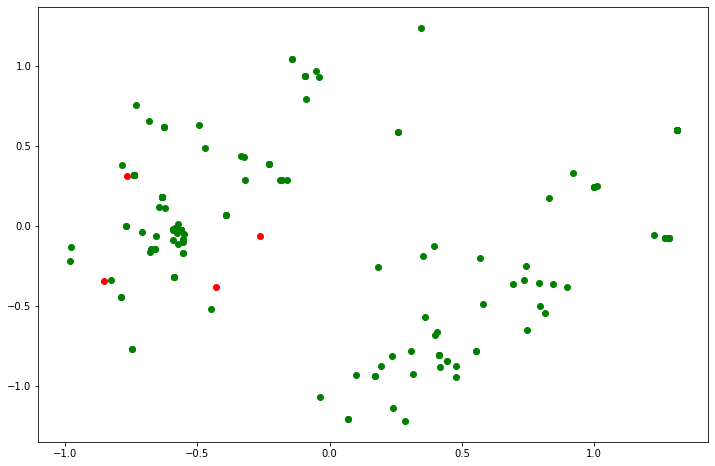

33 pol_na


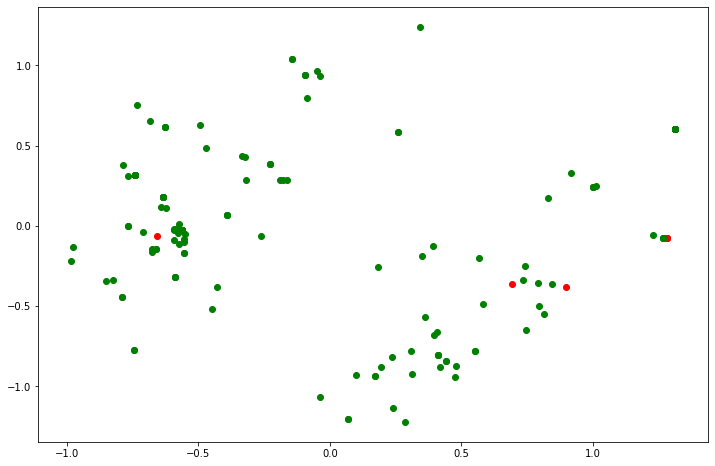

In [17]:
from matplotlib import pyplot as plt
dimension_x = 0
dimension_y = 2
plt.rcParams["figure.figsize"] = (12,8)
plt.scatter(x=coordinates[:,dimension_x],y=coordinates[:,dimension_y])
for i,row in enumerate(dense_coding_table[1:]):
    plt.text(x=coordinates[i,dimension_x],y=coordinates[i,dimension_y],s=dense_coding_table[i+1][0])
    print(coordinates[i,dimension_x],coordinates[i,dimension_y],dense_coding_table[i+1][0])
plt.show()
for i,term in enumerate(header):
    print(i,term)
    present = [j for j,row in enumerate(sparse_coding_table) if row[i] == 1]
    absent  = [j for j,row in enumerate(sparse_coding_table) if row[i] == 0]
    plt.scatter(x=coordinates[present,dimension_x], y=coordinates[present,dimension_y], c = 'r')
    plt.scatter(x=coordinates[absent,dimension_x], y=coordinates[absent,dimension_y], c = 'g')
    #plt.scatter(x=coordinates[no_translation,dimension_x]), y=coordinates[no_translation,dimension_y], c = 'gray')
    plt.show()
    plt.close()